Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,classification_report

In [3]:
from sklearn import svm
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks

IMPORT DATA AND ANALYZE

In [4]:
data_df=pd.read_csv('heart_failure_clinical_records_dataset.csv')
data_df


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
data_df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [7]:
data_df.isna().any().sum()

np.int64(0)

In [13]:
cols = ['#EE0000', '#00EE00']

/tmp/ipython-input-4178729252.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=data_df['DEATH_EVENT'],palette=cols)


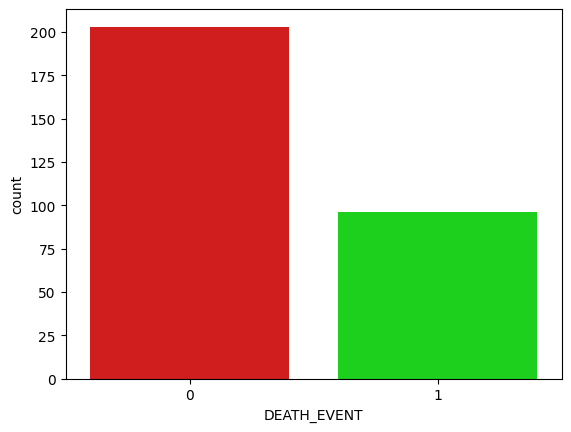

In [14]:
ax=sns.countplot(x=data_df['DEATH_EVENT'],palette=cols)

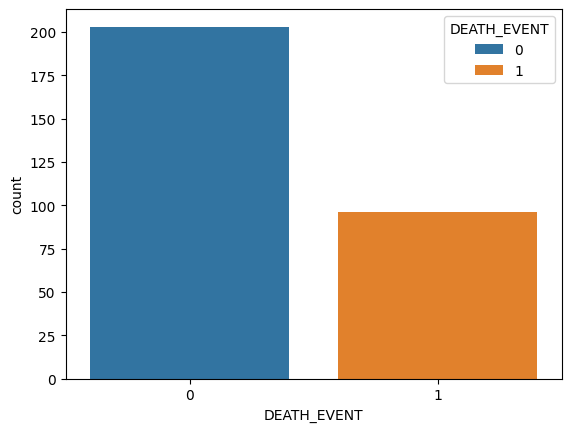

In [15]:
ax=sns.countplot(x='DEATH_EVENT',hue='DEATH_EVENT',data=data_df)

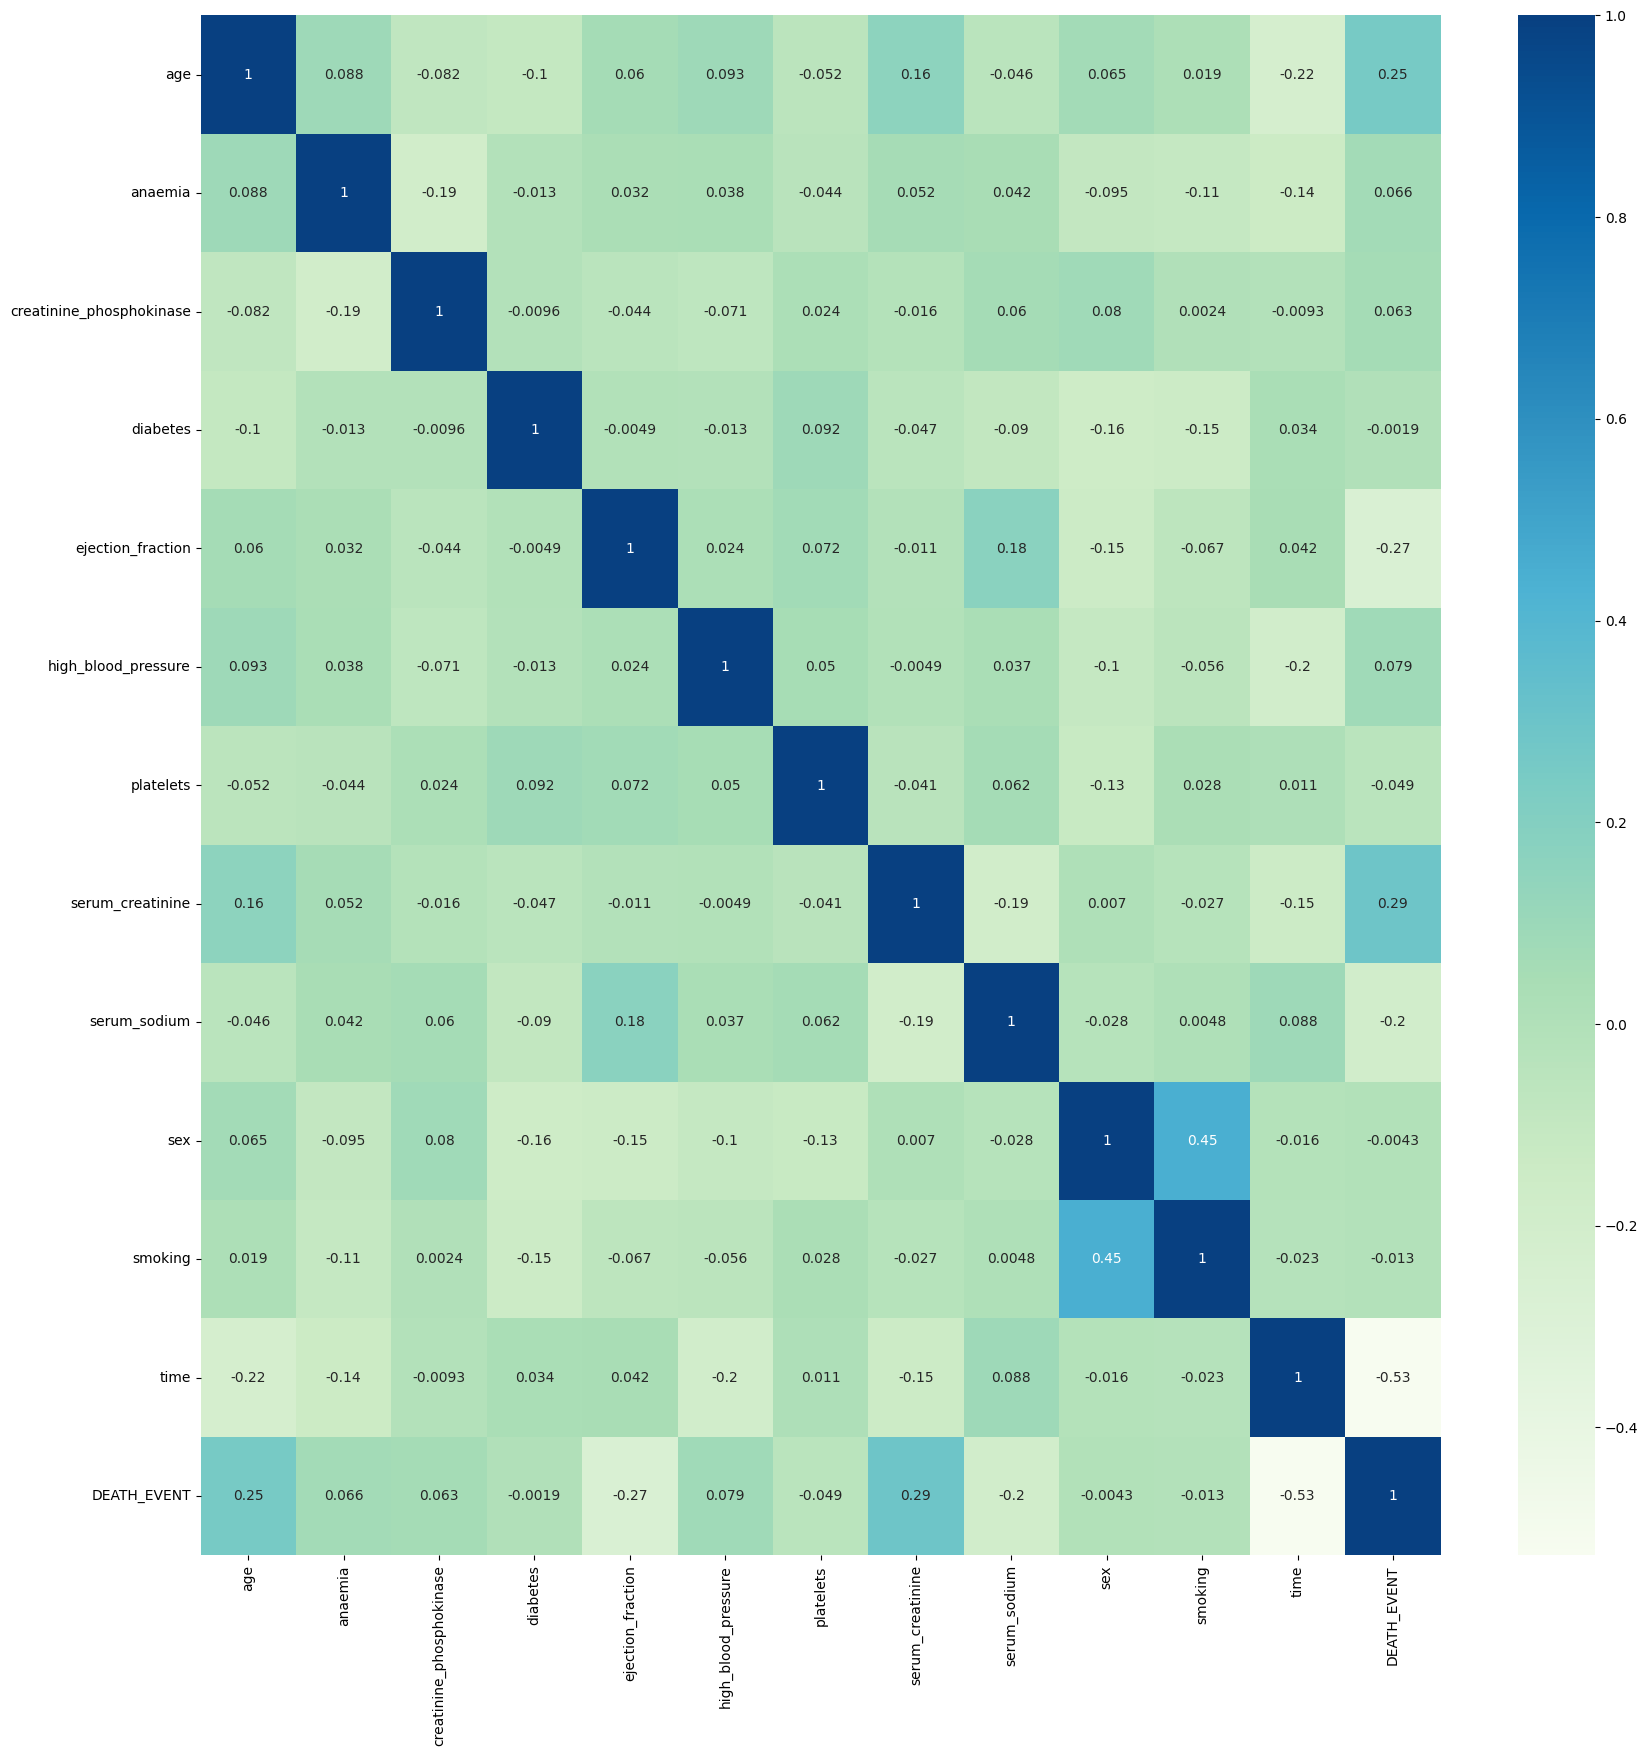

In [16]:
plt.figure(figsize=(20,20))
sns.heatmap(data_df.corr(),cmap="GnBu",annot=True)
plt.show()

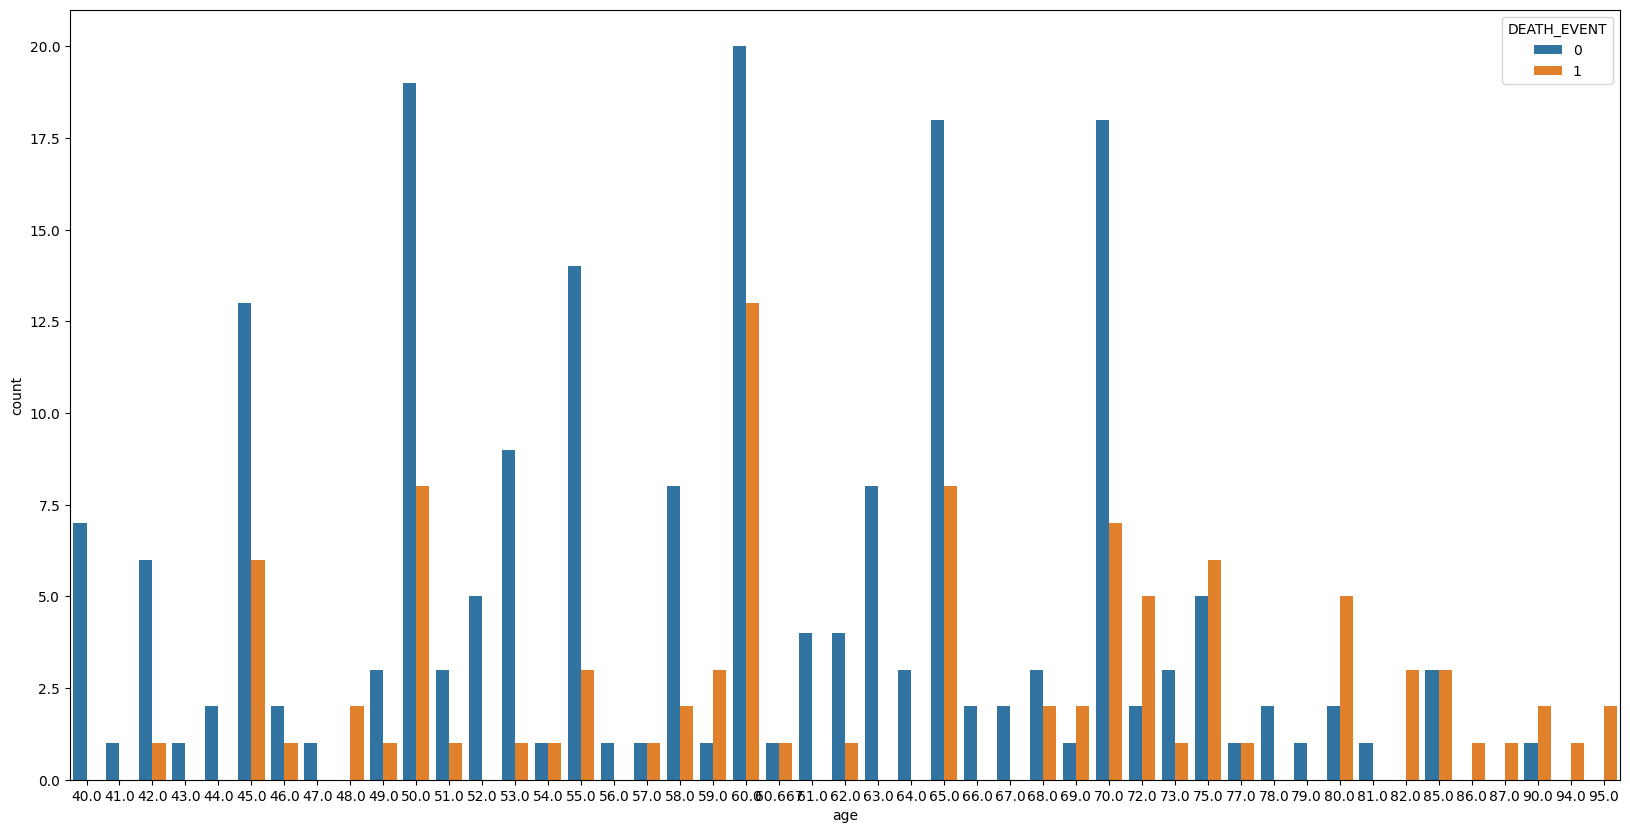

In [19]:
plt.figure(figsize=(20,10))
sns.countplot(x=data_df["age"], data=data_df, hue = "DEATH_EVENT")
plt.show()

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)


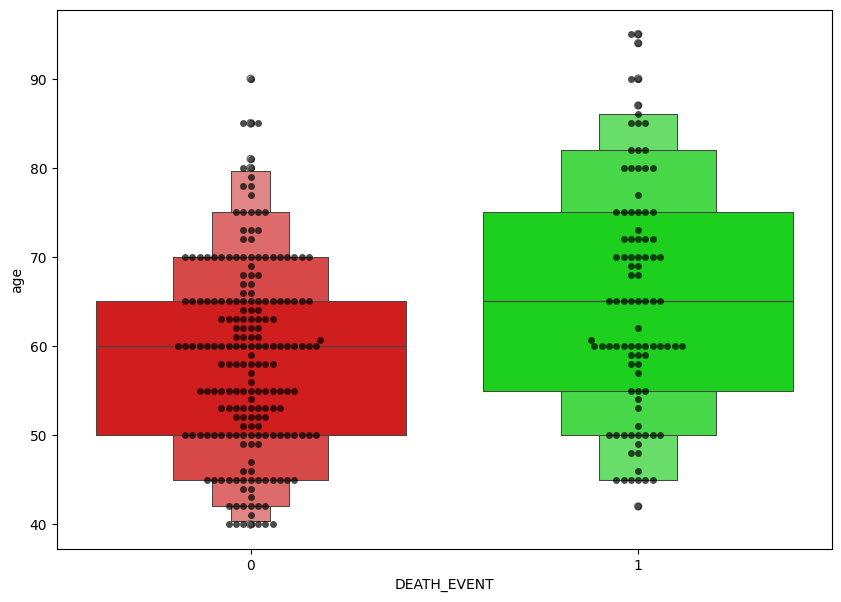

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


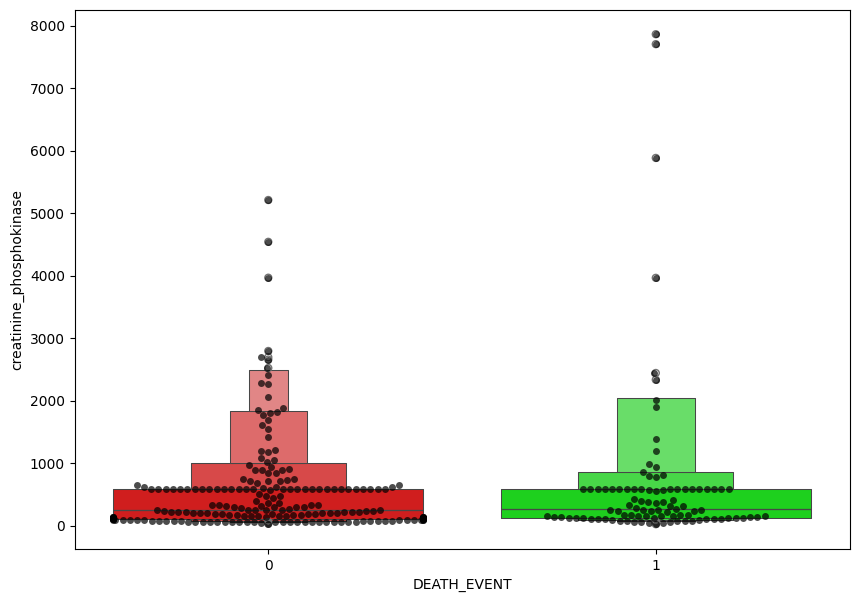

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)


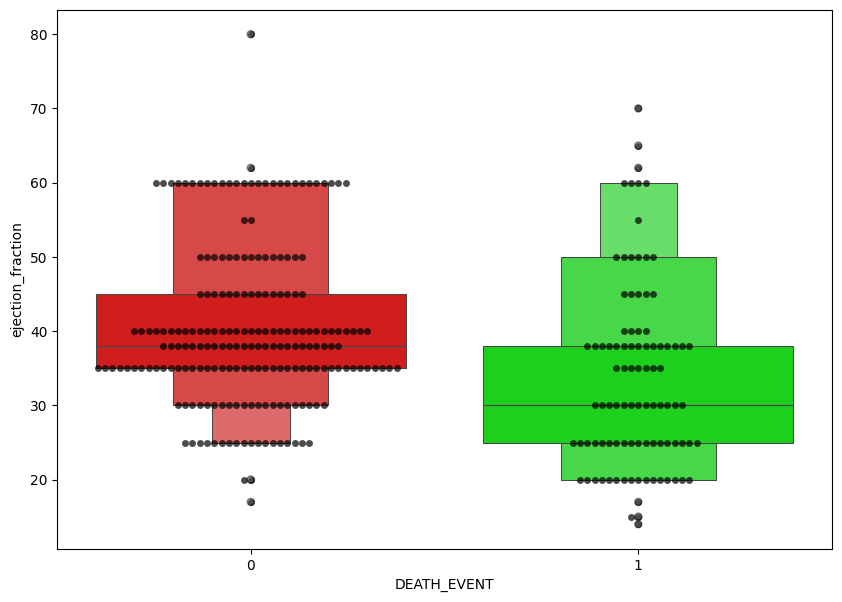

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)


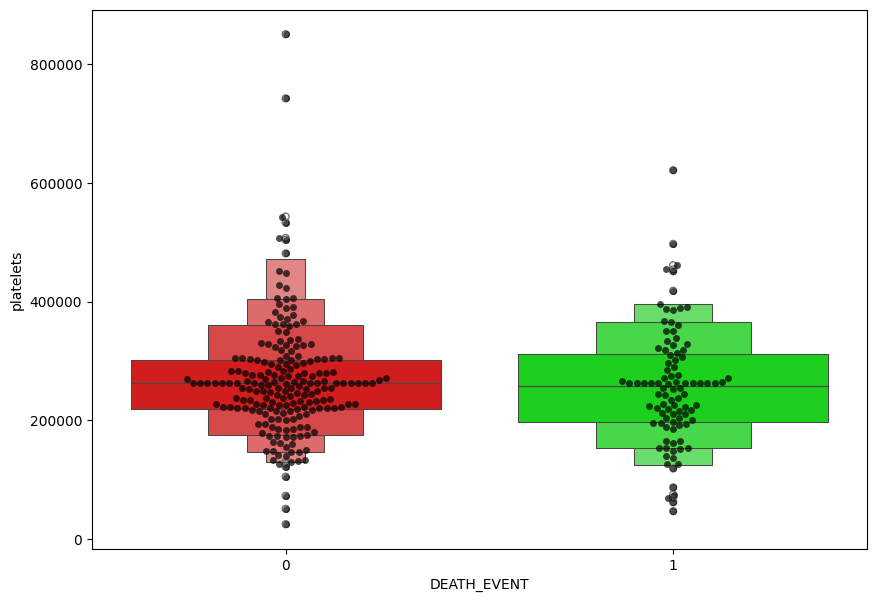

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


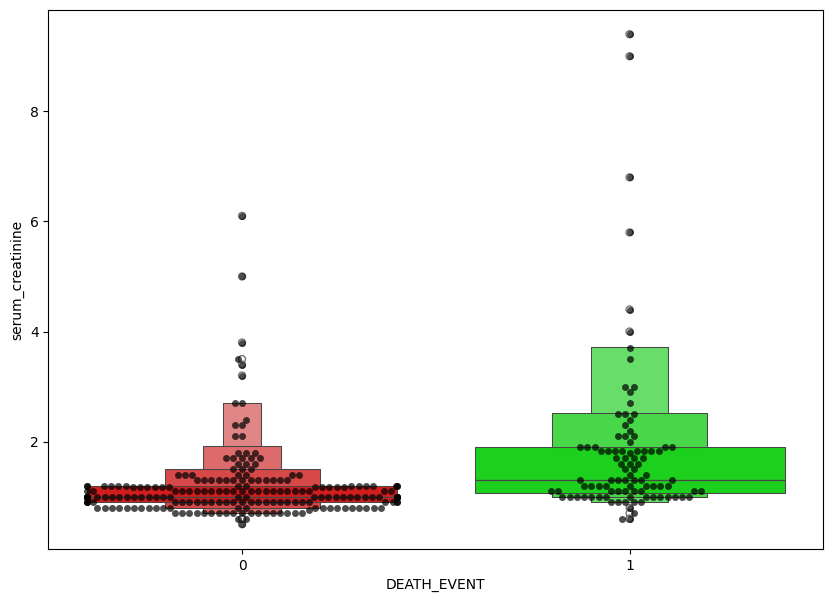

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)


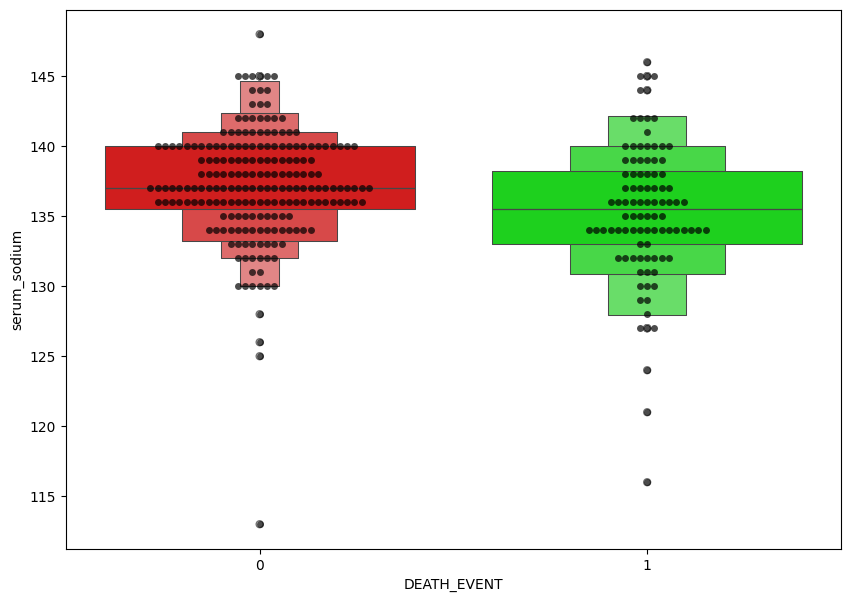

/tmp/ipython-input-1584669515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)


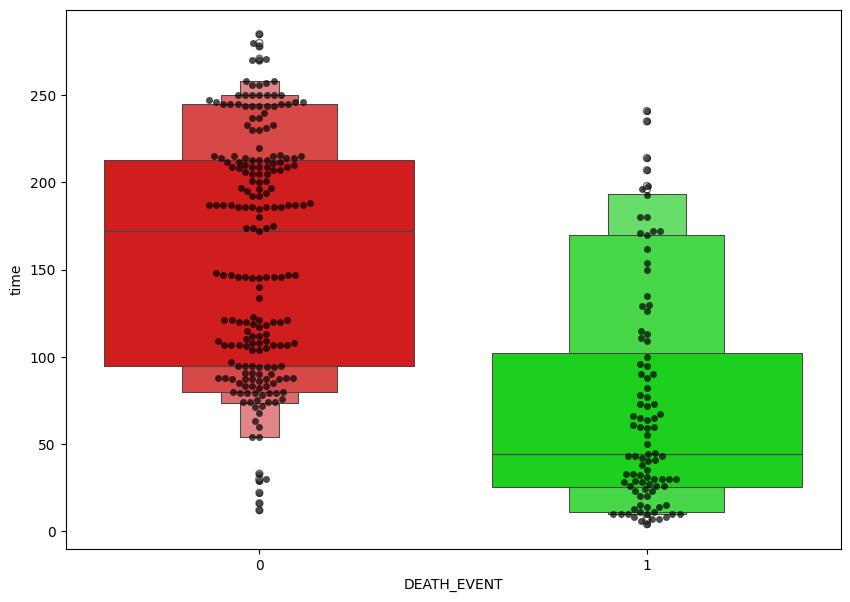

In [20]:
features = ["age","creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine",
"serum_sodium", "time"]
for i in features:
    plt. figure(figsize=(10,7))
    sns. swarmplot(x=data_df["DEATH_EVENT"], y=data_df[i], color="black", alpha = 0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i],palette=cols)
    plt.show()

DATA PREPROCESSING

In [21]:
X=data_df.drop(columns='DEATH_EVENT',axis=1)
y=data_df['DEATH_EVENT']

In [22]:
col_names=list(X.columns)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [23]:
X_scaled=pd.DataFrame(X_scaled,columns=col_names)
X_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,-1.629502
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,-1.603691
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,-1.590785
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,-1.590785
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,-1.577879


In [24]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


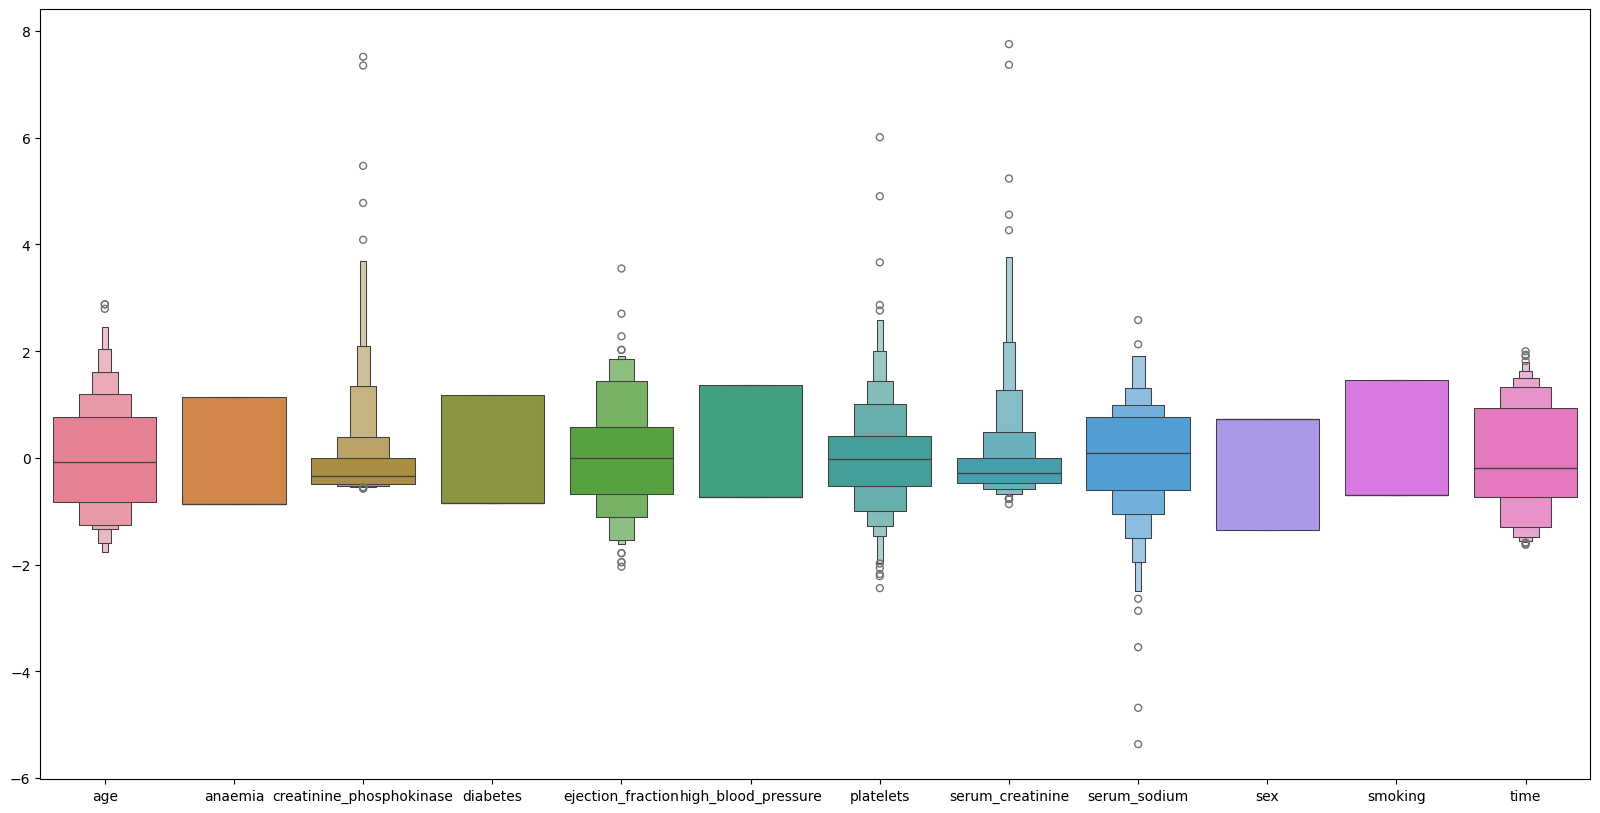

In [25]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3)

MODEL TRAINING

SVM

In [27]:
model1=svm.SVC()

In [28]:
model1.fit(X_train,y_train)

SVC()

In [29]:
model1.predict(X_test)

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0])

In [30]:
np.array(y_test)

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0])

<Axes: >

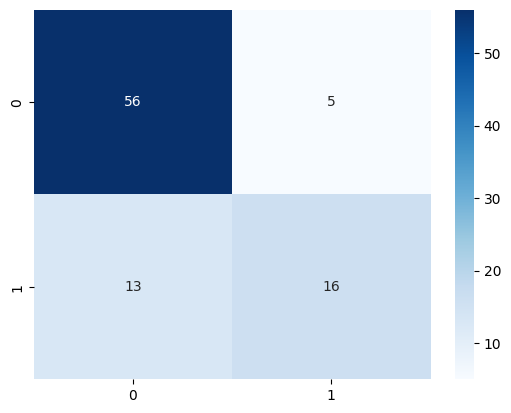

In [32]:
sns.heatmap(confusion_matrix(y_test,model1.predict(X_test)),annot=True,cmap="Blues")

In [33]:
accuracy_score(y_test,model1.predict(X_test))

0.8

In [34]:
print(classification_report(y_test,model1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        61
           1       0.76      0.55      0.64        29

    accuracy                           0.80        90
   macro avg       0.79      0.73      0.75        90
weighted avg       0.80      0.80      0.79        90



ANN

In [58]:
early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
model = Sequential()
model. add (Dense(units = 32, activation='relu',input_dim = 12))
model. add (Dropout (0.25))
model. add (Dense(units = 8, activation= 'relu'))
model. add (Dropout (0.5))
model. add (Dense(units = 1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689 (2.69 KB)

 Trainable params: 689 (2.69 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model. fit(X_train, y_train, batch_size=20, epochs=100, callbacks=[early_stopping], validation_split=0.25)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4952 - loss: 0.7249 - val_accuracy: 0.4528 - val_loss: 0.7050
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4835 - loss: 0.7286 - val_accuracy: 0.4528 - val_loss: 0.6859
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6088 - loss: 0.6448 - val_accuracy: 0.5472 - val_loss: 0.6666
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5605 - loss: 0.6848 - val_accuracy: 0.6226 - val_loss: 0.6484
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5859 - loss: 0.7561 - val_accuracy: 0.6792 - val_loss: 0.6353
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5846 - loss: 0.6806 - val_accuracy: 0.6981 - val_loss: 0.6257
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6202 - loss: 0.6478 - val_accuracy: 0.7736 - val_loss: 0.6180
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5499 - loss: 0.7360 - val_accuracy: 0.7736 - val_loss:

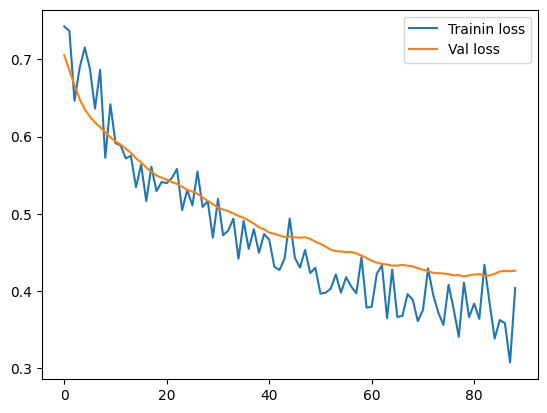

In [62]:
history_df = pd. DataFrame(history.history)
plt.plot(history_df.loc[:, ['loss']], label = "Trainin loss")
plt.plot(history_df.loc[:, ['val_loss']], label ="Val loss")
plt.legend()
plt.show()

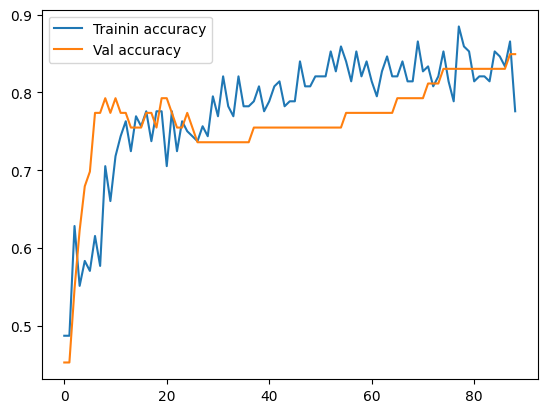

In [63]:
plt.plot(history_df.loc[:, ['accuracy']], label = "Trainin accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']], label ="Val accuracy")
plt.legend()
plt.show()

In [64]:
y_pred=model1.predict(X_test)

In [65]:
y_pred=(y_pred>0.5)

<Axes: >

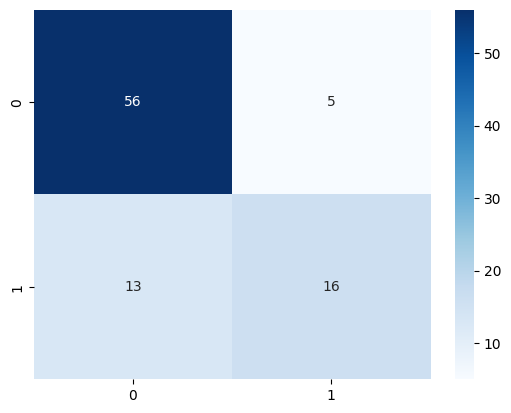

In [66]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, cmap= "Blues")

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        61
           1       0.76      0.55      0.64        29

    accuracy                           0.80        90
   macro avg       0.79      0.73      0.75        90
weighted avg       0.80      0.80      0.79        90

